# 1 Belgium Netherlands Border [40 Marks]
## 1.1 Image Processing and Dataset Creation

In [22]:
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from PIL import Image
import time
from tqdm.notebook import tqdm


USERNAME = "garima.mittal"
DATASET_FILE = "border.png"

Initializing BorderDataset...
Dataset contains 2500 total samples.
Shape of shuffled coordinates: (2500, 2)
Shape of shuffled labels: (2500,)

First 5 samples in shuffled order:
  ((np.float64(0.6938775510204082), np.float64(0.6122448979591837)), 1.0)
  ((np.float64(0.6122448979591837), np.float64(0.8367346938775511)), 1.0)
  ((np.float64(0.7755102040816326), np.float64(0.0)), 0.0)
  ((np.float64(0.8979591836734694), np.float64(0.5102040816326531)), 0.0)
  ((np.float64(0.14285714285714285), np.float64(0.8775510204081632)), 0.0)

Visualizing the generated binary mask...


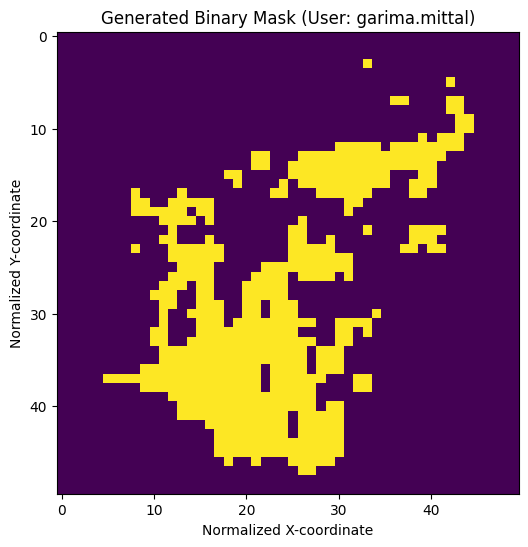

In [23]:
class BorderDataset:
    """
    Handles loading the border image, creating a binary mask, and providing normalized coordinates and labels
    """
    def __init__(self, image_path):
        """
        Initializes the dataset from the image file
        """
        # Load the image and convert to a numpy array
        img = Image.open(image_path).convert("RGB")
        img_array = np.array(img)
        
        # 1. Binary Mask Conversion
        # We define purple as 1 (Belgium) and orange as 0 (Netherlands)
        purple_color_rgb = (138, 43, 226)
        # Create a boolean mask where pixels match the purple color
        self.mask = np.all(img_array == purple_color_rgb, axis=-1).astype(np.float32)
        
        self.height, self.width = self.mask.shape
        
        # 2. Create normalized (x, y) coordinates and corresponding labels (L)
        # Create a grid of coordinates and normalize them to the range [0, 1]
        y_coords, x_coords = np.mgrid[0:self.height, 0:self.width]
        
        normalized_x = x_coords / (self.width - 1)
        normalized_y = y_coords / (self.height - 1)
        
        # Store all coordinates and labels, flattened
        self.all_coords = np.stack([normalized_x.ravel(), normalized_y.ravel()], axis=1)
        self.all_labels = self.mask.ravel()

    def __len__(self):
        """
        Returns the total number of pixels in the image
        """
        return len(self.all_labels)

    def get_shuffled_data(self):
        """
        Randomly returns all the pixels from the image in a shuffled order
        """
        # Generate a new set of shuffled indices each time the method is called
        shuffled_indices = np.random.permutation(len(self))
        return self.all_coords[shuffled_indices], self.all_labels[shuffled_indices]

    def visualize_mask(self):
        """
        Helper function to display the generated binary mask
        """
        plt.figure(figsize=(6, 6))
        plt.imshow(self.mask, cmap='viridis', origin='upper')
        plt.title(f"Generated Binary Mask (User: {USERNAME})")
        plt.xlabel("Normalized X-coordinate")
        plt.ylabel("Normalized Y-coordinate")
        plt.show()

# Demonstration of the Dataset Class
print("Initializing BorderDataset...")
# Create an instance of the dataset
dataset = BorderDataset(DATASET_FILE)

# Print some basic information
print(f"Dataset contains {len(dataset)} total samples.")

# Get shuffled data and verify its shape
coords, labels = dataset.get_shuffled_data()
print(f"Shape of shuffled coordinates: {coords.shape}") # Should be (2500, 2)
print(f"Shape of shuffled labels: {labels.shape}")       # Should be (2500,)

# Display a few samples in the required format: ((x, y), L)
print("\nFirst 5 samples in shuffled order:")
for i in range(5):
    print(f"  ({tuple(coords[i])}, {labels[i]})")

# Visualize the resulting binary mask to confirm correctness
print("\nVisualizing the generated binary mask...")
dataset.visualize_mask()

## 1.2 Neural Network Implementation from Scratch

In [24]:
class Activation:
    """
    Base class for activation functions
    """
    def forward(self, x):
        raise NotImplementedError
    def backward(self, grad_output):
        raise NotImplementedError

class ReLU(Activation):
    def forward(self, x):
        self.input = x
        return np.maximum(0, x)
    def backward(self, grad_output):
        return grad_output * (self.input > 0)

class Tanh(Activation):
    def forward(self, x):
        self.output = np.tanh(x)
        return self.output
    def backward(self, grad_output):
        return grad_output * (1 - self.output**2)

class Sigmoid(Activation):
    def forward(self, x):
        self.output = 1 / (1 + np.exp(-np.clip(x, -500, 500)))
        return self.output
    def backward(self, grad_output):
        return grad_output * self.output * (1 - self.output)

class Identity(Activation):
    def forward(self, x):
        return x
    def backward(self, grad_output):
        return grad_output

In [25]:
class Loss:
    """
    Base class for loss functions
    """
    def forward(self, y_pred, y_true):
        raise NotImplementedError
    def backward(self):
        raise NotImplementedError

class MSELoss(Loss):
    def forward(self, y_pred, y_true):
        self.y_pred, self.y_true = y_pred, y_true
        return np.mean((y_pred - y_true)**2)
    def backward(self):
        return 2 * (self.y_pred - self.y_true) / self.y_true.shape[0]

class BCELoss(Loss):
    def forward(self, y_pred, y_true):
        y_pred = np.clip(y_pred, 1e-9, 1 - 1e-9)
        self.y_pred, self.y_true = y_pred, y_true
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    def backward(self):
        grad = (self.y_pred - self.y_true) / (self.y_pred * (1 - self.y_pred))
        return grad / self.y_true.shape[0]

In [26]:
class Linear:
    """
    A fully connected Linear layer
    """
    def __init__(self, input_width: int, output_width: int, activation: Activation):
        # Forward pass data
        self.weights = np.random.randn(input_width, output_width) * np.sqrt(2.0 / input_width)
        self.biases = np.zeros((1, output_width))
        self.activation = activation
        
        # Backward pass data
        self.input = None
        self.output = None
        self.grad_weights_cumulative = np.zeros_like(self.weights)
        self.grad_biases_cumulative = np.zeros_like(self.biases)

    def forward(self, inputs):
        self.input = inputs
        pre_activation = np.dot(inputs, self.weights) + self.biases
        self.output = self.activation.forward(pre_activation)
        return self.output

    def backward(self, grad_output):
        grad_pre_activation = self.activation.backward(grad_output)
        grad_weights = np.dot(self.input.T, grad_pre_activation)
        grad_biases = np.sum(grad_pre_activation, axis=0, keepdims=True)
        
        # Add to cumulative gradients
        self.grad_weights_cumulative += grad_weights
        self.grad_biases_cumulative += grad_biases
        
        return np.dot(grad_pre_activation, self.weights.T)

In [27]:
class Model:
    """
    An MLP Model that encapsulates layers and manages the training process
    """
    def __init__(self, layers: list, loss_function_type: str = 'BCE'):
        self.layers = layers
        if loss_function_type == 'BCE':
            self.loss_fn = BCELoss()
        elif loss_function_type == 'MSE':
            self.loss_fn = MSELoss()
        else:
            raise ValueError("Unsupported loss function type.")

    def forward(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def backward(self):
        grad = self.loss_fn.backward()
        for layer in reversed(self.layers):
            grad = layer.backward(grad)

    def train(self, x_batch, y_batch):
        """
        Performs a forward and backward pass, accumulating gradients
        """
        y_pred = self.forward(x_batch)
        loss = self.loss_fn.forward(y_pred, y_batch)
        self.backward()
        # Note: Gradients are added to cumulative buffers inside each layer's backward pass
        return loss

    def update(self, learning_rate: float):
        """
        Updates model parameters using cumulative gradients and then resets them
        """
        for layer in self.layers:
            layer.weights -= learning_rate * layer.grad_weights_cumulative
            layer.biases -= learning_rate * layer.grad_biases_cumulative
        self.zero_grad()

    def zero_grad(self):
        """
        Resets cumulative gradients in all layers to zero
        """
        for layer in self.layers:
            layer.grad_weights_cumulative.fill(0)
            layer.grad_biases_cumulative.fill(0)
            
    def predict(self, x):
        """
        Performs a forward pass to get predictions
        """
        return self.forward(x)
        
    def count_params(self):
        return sum(layer.weights.size + layer.biases.size for layer in self.layers)

    def save_to(self, path):
        """
        Saves all model parameters to a .npz file
        """
        params = {f'w{i}': layer.weights for i, layer in enumerate(self.layers)}
        params.update({f'b{i}': layer.biases for i, layer in enumerate(self.layers)})
        np.savez(path, **params)

    def load_from(self, path: str):
        """
        Loads model parameters from a .npz file
        """
        data = np.load(path)
        if len(data.files) != len(self.layers) * 2:
            raise ValueError("Architecture mismatch: incorrect number of layers.")
        for i, layer in enumerate(self.layers):
            w_shape, b_shape = data[f'w{i}'].shape, data[f'b{i}'].shape
            if layer.weights.shape != w_shape or layer.biases.shape != b_shape:
                raise ValueError(f"Architecture mismatch: shape of layer {i} is incorrect.")
            layer.weights = data[f'w{i}']
            layer.biases = data[f'b{i}']

In [47]:
import os, json, time, datetime
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

class Trainer:
    """
    Encapsulates the entire training and evaluation loop for a model.
    (Enhanced to save plots, params, and run metadata as required by 1.4)
    """
    def __init__(self, model, dataset, hparams, runs_root="runs"):
        self.model = model
        self.dataset = dataset
        self.hparams = hparams
        if hparams.get('seed') is not None:
            np.random.seed(hparams['seed'])

        # ---- unique run folder
        ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        self.run_name = f"run_{ts}"
        self.run_dir = os.path.join(runs_root, self.run_name)
        os.makedirs(self.run_dir, exist_ok=True)

        # ---- storage for plotting/logging
        self.batch_loss_history = []      # per-batch loss
        self.samples_seen_history = []    # cumulative samples (x-axis)

    def _save_model_params(self, path_npz):
        """
        Save final model parameters to NPZ.
        Attempts to find layers with W/b (Linear layers).
        """
        params = {}
        # Try common places for layers
        candidate_layers = []
        if hasattr(self.model, "layers"):
            candidate_layers = self.model.layers
        elif hasattr(self.model, "net") and hasattr(self.model.net, "layers"):
            candidate_layers = self.model.net.layers

        for i, L in enumerate(candidate_layers):
            if hasattr(L, "W") and hasattr(L, "b"):
                params[f"W_{i}"] = L.W
                params[f"b_{i}"] = L.b
        if params:
            np.savez(path_npz, **params)

    def _plot_and_save_loss_vs_samples(self, title_suffix=""):
        """
        Create and save the loss vs. samples seen plot. Also show it in the notebook.
        """
        if not self.samples_seen_history:
            return
        plt.figure(figsize=(7, 4))
        plt.plot(self.samples_seen_history, self.batch_loss_history, linewidth=1.5)
        plt.xlabel("Samples seen")
        plt.ylabel("Batch loss")
        plt.title(f"Training Loss vs Samples Seen {title_suffix}")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        out_png = os.path.join(self.run_dir, "loss_vs_samples.png")
        plt.savefig(out_png, dpi=150)
        plt.show()

    def _save_batch_log_csv(self):
        """
        Save per-batch samples/loss to CSV for reproducibility & WandB-style logging.
        """
        if not self.samples_seen_history:
            return
        import csv
        out_csv = os.path.join(self.run_dir, "training_loss.csv")
        with open(out_csv, "w", newline="") as f:
            w = csv.writer(f)
            w.writerow(["batch_index", "samples_seen", "loss"])
            for i, (s, l) in enumerate(zip(self.samples_seen_history, self.batch_loss_history)):
                w.writerow([i, int(s), float(l)])

    def fit(self):
        """
        Runs the main training loop. (Training logic unchanged.)
        """
        start_time = time.time()
        epoch_losses = []
        indices = np.arange(len(self.dataset))

        total_samples_seen = 0  # cumulative samples (used for x-axis)

        for epoch in range(self.hparams['epochs']):
            np.random.shuffle(indices)
            epoch_loss_total = 0
            num_batches = len(self.dataset) // self.hparams['batch_size']

            pbar_desc = f"Epoch {epoch+1}/{self.hparams['epochs']}"
            pbar_iter = tqdm(range(num_batches), desc=pbar_desc, leave=False) \
                        if not self.hparams.get('quiet', False) else range(num_batches)

            for i in pbar_iter:
                start, end = i * self.hparams['batch_size'], (i + 1) * self.hparams['batch_size']
                batch_indices = indices[start:end]
                x_batch = self.dataset.all_coords[batch_indices]
                y_batch = self.dataset.all_labels[batch_indices]

                # ---- account for samples seen (note in 1.4 about batch_size & grad_accum)
                total_samples_seen += x_batch.shape[0]

                # forward / loss
                y_pred = self.model.forward(x_batch)
                loss = self.model.loss_fn.forward(y_pred, y_batch.reshape(-1, 1))

                # backward (no change)
                self.model.backward()
                epoch_loss_total += loss

                # record per-batch logs for plotting
                self.batch_loss_history.append(float(loss))
                self.samples_seen_history.append(int(total_samples_seen))

                # update after grad_accum_steps (no change)
                if (i + 1) % self.hparams['grad_accum_steps'] == 0:
                    self.model.update(self.hparams['lr'])

                # live tqdm postfix
                if not self.hparams.get('quiet', False):
                    try:
                        pbar_iter.set_postfix({"loss": f"{loss:.5f}", "samples": total_samples_seen})
                    except Exception:
                        pass

            avg_loss = epoch_loss_total / num_batches if num_batches > 0 else 0
            epoch_losses.append(avg_loss)

            # early stopping (unchanged logic)
            if epoch >= self.hparams['patience']:
                past_loss = epoch_losses[epoch - self.hparams['patience']]
                improvement = (past_loss - avg_loss) / past_loss if past_loss > 0 else 0
                if improvement < self.hparams['threshold']:
                    if not self.hparams.get('quiet', False):
                        print(f"\nEarly stopping at epoch {epoch+1}.")
                    break

        # Final evaluation (unchanged)
        predictions = self.model.forward(self.dataset.all_coords)
        pred_labels = (predictions > 0.5).astype(int).flatten()

        results = {
            'accuracy': float(np.mean(pred_labels == self.dataset.all_labels)),
            'final_loss': float(epoch_losses[-1] if epoch_losses else 0),
            'epochs': epoch + 1,
            'time': float(time.time() - start_time),
            'samples_seen': int(total_samples_seen),
            'run_dir': self.run_dir,
            'run_name': self.run_name,
        }

        # ---- POST: save everything required by 1.4
        # 1) Plot & save loss vs samples seen
        self._plot_and_save_loss_vs_samples(title_suffix=f"(batch={self.hparams['batch_size']}, accum={self.hparams['grad_accum_steps']})")
        self._save_batch_log_csv()

        # 2) Save final model parameters
        self._save_model_params(os.path.join(self.run_dir, "model_params.npz"))

        # 3) Save run summary (hparams, epoch losses, final metrics)
        summary = {
            "hparams": {k: (int(v) if isinstance(v, (np.integer,)) else v) for k, v in self.hparams.items()},
            "epoch_losses": [float(x) for x in epoch_losses],
            "batch_losses": [float(x) for x in self.batch_loss_history],
            "samples_seen_history": [int(x) for x in self.samples_seen_history],
            "results": results,
        }
        with open(os.path.join(self.run_dir, "run_summary.json"), "w") as f:
            json.dump(summary, f, indent=2)

        # 4) Save the 3-panel comparison figure using your provided helper
        try:
            visualize_single_run(self.model, self.dataset, self.run_dir, self.run_name)
        except Exception as e:
            # don't fail training if visualization has issues
            print(f"[WARN] visualize_single_run failed: {e}")

        return results

print("Trainer class (with saving & plotting per 1.4) is defined.")


Trainer class (with saving & plotting per 1.4) is defined.


In [48]:
def perform_sanity_checks():
    """
    Runs the two required sanity checks: solving the XOR problem and verifying the backpropagation gradients numerically.
    """
    
    # 1.3.1: The XOR Problem
    print("="*70)
    print("1.3.1: Running Sanity Check for the XOR Problem")
    print("="*70)
    
    # 1. Create a dataset for the XOR function
    X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y_xor = np.array([[0], [1], [1], [0]])
    
    # 2. Train and test a suitable architecture
    # NOTE: Using ReLU activation as it matches the He initialization in the Linear layer
    xor_model = Model(
        layers=[
            Linear(input_width=2, output_width=4, activation=ReLU()),
            Linear(input_width=4, output_width=1, activation=Sigmoid())
        ],
        loss_function_type='BCE'
    )
    
    print("Training a 2-4-1 model on the XOR dataset...")
    # Simplified training loop for this small task
    for epoch in range(3000):
        loss = xor_model.train(X_xor, y_xor)
        xor_model.update(learning_rate=0.05)
        if (epoch + 1) % 500 == 0:
            print(f"  Epoch {epoch+1}, Loss: {loss:.6f}")

    # 3. Ensure the model converges to 100% accuracy
    predictions = xor_model.predict(X_xor)
    predicted_labels = (predictions > 0.5).astype(int)
    accuracy = np.mean(predicted_labels == y_xor)

    print(f"\n[XOR Result] Final Accuracy: {accuracy*100:.2f}%")
    if accuracy == 1.0:
        print("SUCCESS: Model correctly converged to 100% accuracy.")
    else:
        print("FAILURE: Model did not solve the XOR problem.")
        
    # 1.3.2: Gradient Approximation
    print("\n" + "="*70)
    print("1.3.2: Running Sanity Check for Gradient Approximation")
    print("="*70)
    
    # Use a small model and a single data point with non-zero inputs
    grad_check_model = Model(
        [Linear(2, 2, Tanh()), Linear(2, 1, Sigmoid())], 'BCE'
    )
    x_sample = np.array([[1, 1]]) # Input where all features are non-zero
    y_sample = np.array([[0]]) # Corresponding XOR target
    epsilon = 1e-5

    # Calculate the backpropagated gradients first
    grad_check_model.train(x_sample, y_sample)
    
    # Check the gradient for the first weight in the first layer
    layer_to_check = grad_check_model.layers[0]
    backprop_grad = layer_to_check.grad_weights_cumulative[0, 0]
    
    # Calculate Numerical Gradient
    original_weight = layer_to_check.weights[0, 0]
    
    # Loss for (w + epsilon)
    layer_to_check.weights[0, 0] = original_weight + epsilon
    loss_plus = grad_check_model.loss_fn.forward(grad_check_model.predict(x_sample), y_sample)
    
    # Loss for (w - epsilon)
    layer_to_check.weights[0, 0] = original_weight - epsilon
    loss_minus = grad_check_model.loss_fn.forward(grad_check_model.predict(x_sample), y_sample)
    
    layer_to_check.weights[0, 0] = original_weight # Restore weight
    
    # Compute numerical gradient using the formula
    numerical_grad = (loss_plus - loss_minus) / (2 * epsilon)
    
    # Compare Gradients
    denominator = max(abs(numerical_grad), abs(backprop_grad), 1e-8)
    relative_error = abs(numerical_grad - backprop_grad) / denominator

    print(f"[Gradient Check] Layer 0, Weight (0,0):")
    print(f"  - Backpropagated Gradient: {backprop_grad:.6f}")
    print(f"  - Numerical Gradient:      {numerical_grad:.6f}")
    print(f"  - Relative Error:          {relative_error:.2e}")
    
    if relative_error < 1e-5:
        print(f"SUCCESS: Gradients match closely.")
    else:
        print(f"FAILURE: Gradients do not match.")

# Run the sanity checks
perform_sanity_checks()

1.3.1: Running Sanity Check for the XOR Problem
Training a 2-4-1 model on the XOR dataset...
  Epoch 500, Loss: 0.230300
  Epoch 1000, Loss: 0.065329
  Epoch 1500, Loss: 0.035458
  Epoch 2000, Loss: 0.023717
  Epoch 2500, Loss: 0.017606
  Epoch 3000, Loss: 0.013911

[XOR Result] Final Accuracy: 100.00%
SUCCESS: Model correctly converged to 100% accuracy.

1.3.2: Running Sanity Check for Gradient Approximation
[Gradient Check] Layer 0, Weight (0,0):
  - Backpropagated Gradient: 0.759717
  - Numerical Gradient:      0.759717
  - Relative Error:          4.46e-11
SUCCESS: Gradients match closely.


Training ExampleRun_Depth4_Width64...



Early stopping at epoch 154.


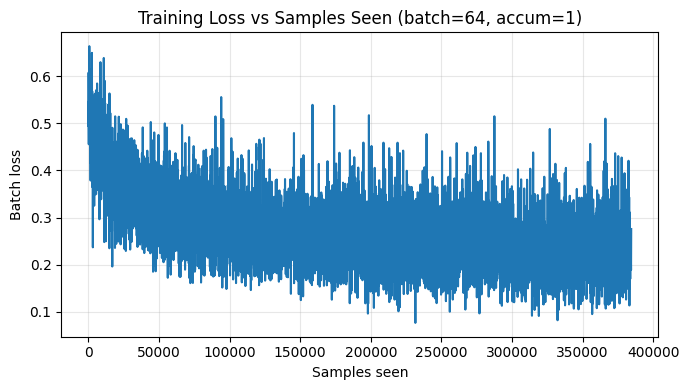


Final Accuracy: 90.76%
Final Loss: 0.245325
Saved visualization to 'data'


In [50]:
# Define a representative architecture and hyperparameters
example_hparams = {
    'lr': 0.1, 'batch_size': 64, 'grad_accum_steps': 1,
    'epochs': 500, 'patience': 50, 'threshold': 0.01,
    'seed': 42, 'quiet': False
}

example_layers = [
    Linear(2, 64, ReLU()),
    Linear(64, 64, ReLU()),
    Linear(64, 64, ReLU()),
    Linear(64, 1, Sigmoid())
]

run_name = "ExampleRun_Depth4_Width64"

# Build and train the model
print(f"Training {run_name}...")
model = Model(example_layers)
trainer = Trainer(model, dataset, example_hparams)
results = trainer.fit()

print(f"\nFinal Accuracy: {results['accuracy']*100:.2f}%")
print(f"Final Loss: {results['final_loss']:.6f}")

# Generate and save the 3-panel visualization
run_dir = "data"
visualize_single_run(model, dataset, run_dir, run_name)
print(f"Saved visualization to '{run_dir}'")


Experiment: Varying Network Depth
  Training Depth_3-Width_64...


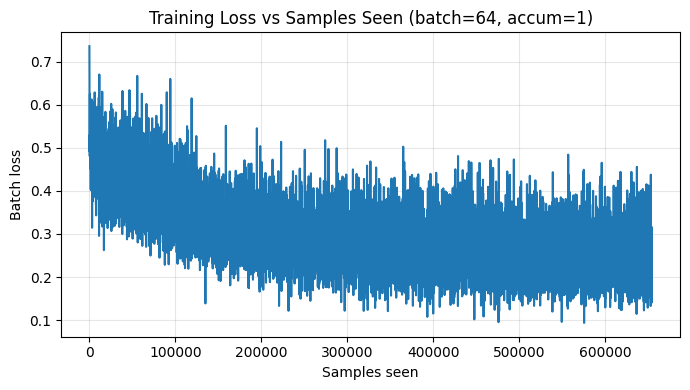

  Training Depth_5-Width_64...


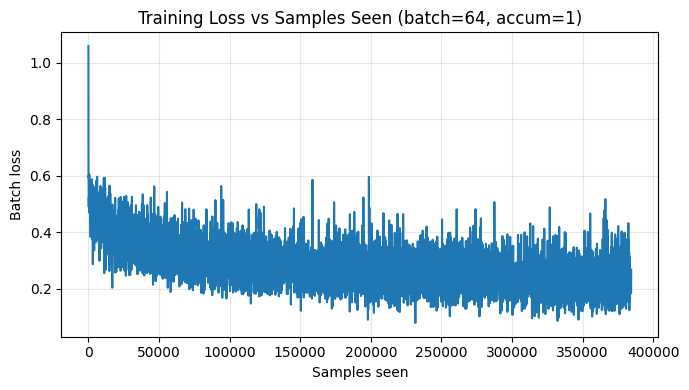

  Training Depth_7-Width_64...


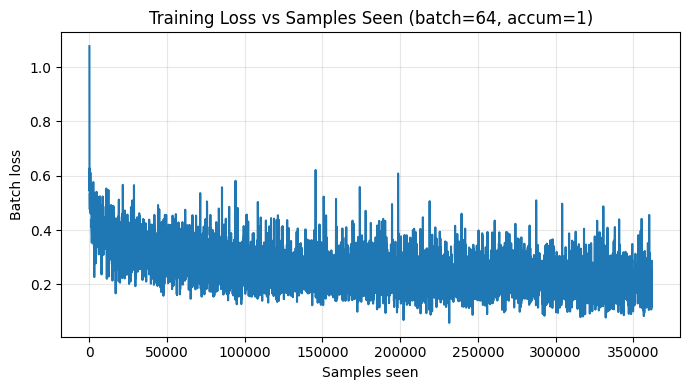

  Training Depth_9-Width_64...


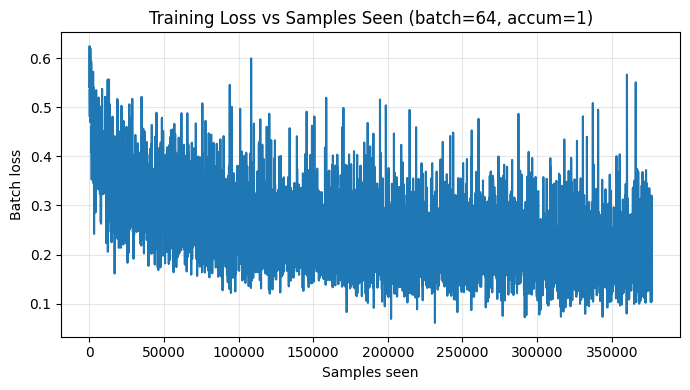


Experiment: Varying Network Width
  Training Width_16-Depth_5...


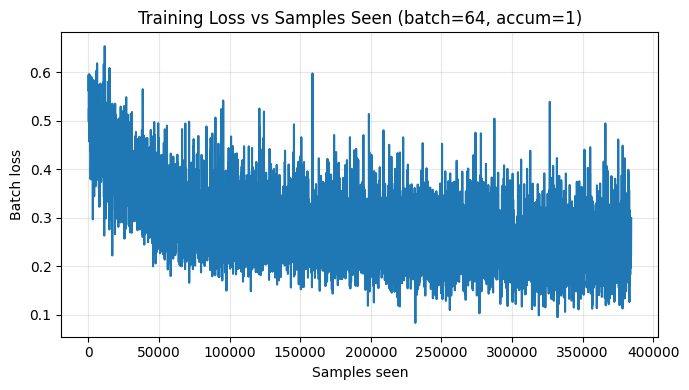

  Training Width_32-Depth_5...


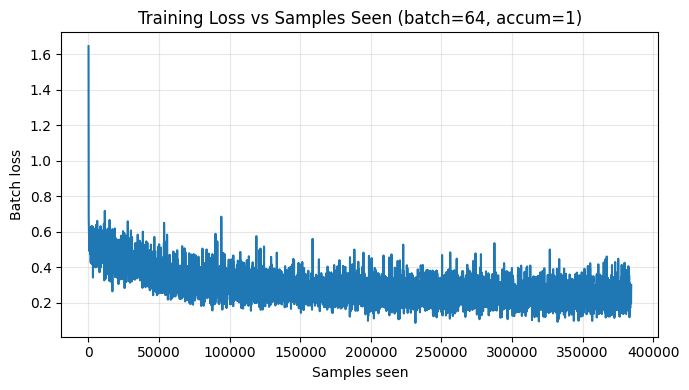

  Training Width_64-Depth_5...


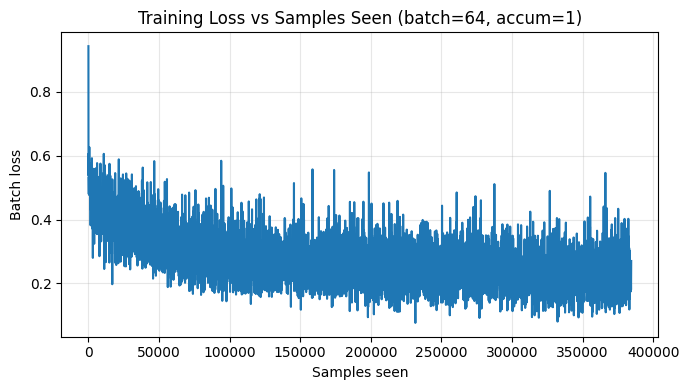

  Training Width_128-Depth_5...


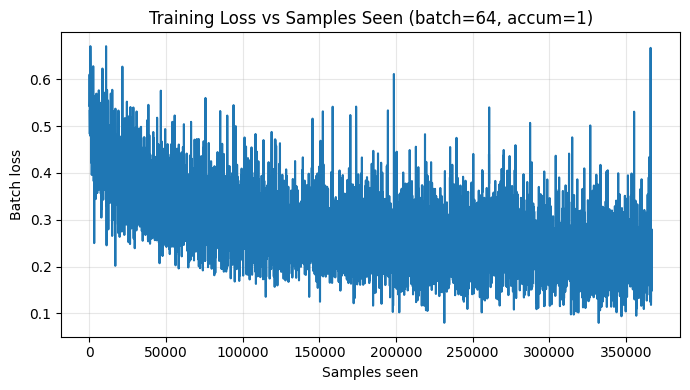

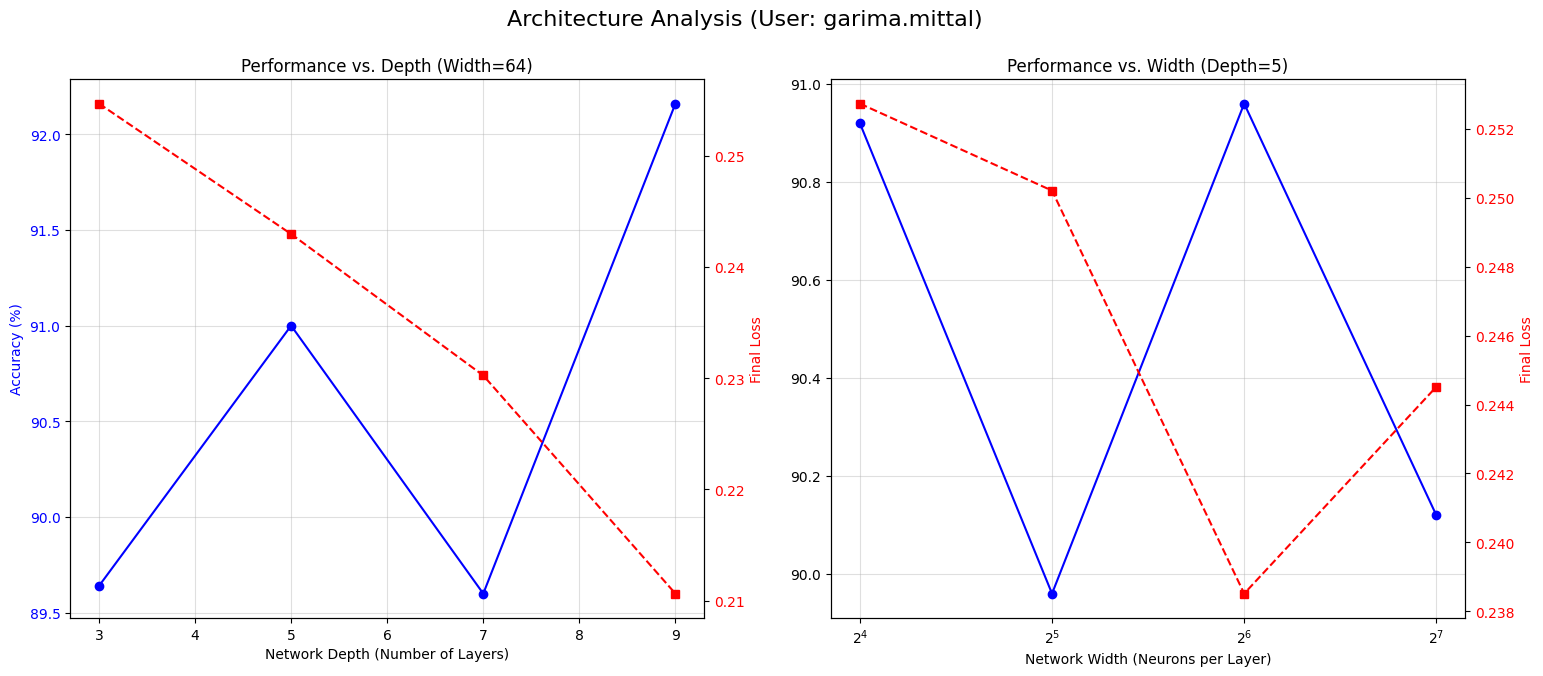

In [51]:
base_hparams = {
    'lr': 0.05, 'batch_size': 64, 'grad_accum_steps': 1,
    'epochs': 500, 'patience': 50, 'threshold': 0.01,
    'seed': 42, 'quiet': True
}

# Experiment 1: Varying Network Depth
print("\nExperiment: Varying Network Depth")
depths_to_test = [3, 5, 7, 9]
fixed_width = 64
depth_results = []
for depth in depths_to_test:
    run_name = f"Depth_{depth}-Width_{fixed_width}"
    print(f"  Training {run_name}...")
    
    layers = [Linear(2, fixed_width, ReLU())]
    layers += [Linear(fixed_width, fixed_width, ReLU()) for _ in range(depth - 2)]
    layers.append(Linear(fixed_width, 1, Sigmoid()))
    
    model = Model(layers)
    trainer = Trainer(model, dataset, base_hparams)
    results = trainer.fit()
    depth_results.append({'depth': depth, **results})

# Experiment 2: Varying Network Width
print("\nExperiment: Varying Network Width")
widths_to_test = [16, 32, 64, 128]
fixed_depth = 5
width_results = []
for width in widths_to_test:
    run_name = f"Width_{width}-Depth_{fixed_depth}"
    print(f"  Training {run_name}...")
    
    layers = [Linear(2, width, ReLU())]
    layers += [Linear(width, width, ReLU()) for _ in range(fixed_depth - 2)]
    layers.append(Linear(width, 1, Sigmoid()))
    
    model = Model(layers)
    trainer = Trainer(model, dataset, base_hparams)
    results = trainer.fit()
    width_results.append({'width': width, **results})

# Plotting Architecture Results
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
df_depth = pd.DataFrame(depth_results)
df_width = pd.DataFrame(width_results)

# Plot for Depth
axes[0].plot(df_depth['depth'], df_depth['accuracy'] * 100, 'o-', label='Accuracy', color='blue')
axes[0].set_xlabel("Network Depth (Number of Layers)")
axes[0].set_ylabel("Accuracy (%)", color='blue')
axes[0].tick_params(axis='y', labelcolor='blue')
ax0_twin = axes[0].twinx()
ax0_twin.plot(df_depth['depth'], df_depth['final_loss'], 's--', color='red', label='Loss')
ax0_twin.set_ylabel("Final Loss", color='red')
ax0_twin.tick_params(axis='y', labelcolor='red')
axes[0].set_title(f"Performance vs. Depth (Width={fixed_width})")
axes[0].grid(True, alpha=0.4)

# Plot for Width
axes[1].plot(df_width['width'], df_width['accuracy'] * 100, 'o-', label='Accuracy', color='blue')
axes[1].set_xlabel("Network Width (Neurons per Layer)")
ax1_twin = axes[1].twinx()
ax1_twin.plot(df_width['width'], df_width['final_loss'], 's--', color='red', label='Loss')
ax1_twin.set_ylabel("Final Loss", color='red')
ax1_twin.tick_params(axis='y', labelcolor='red')
axes[1].set_title(f"Performance vs. Width (Depth={fixed_depth})")
axes[1].set_xscale('log', base=2)
axes[1].grid(True, alpha=0.4)

fig.suptitle(f"Architecture Analysis (User: {USERNAME})", fontsize=16)
plt.show()


Experiment: Varying Hyperparameters
  Training LR_0.1-Batch_32-Accum_1...


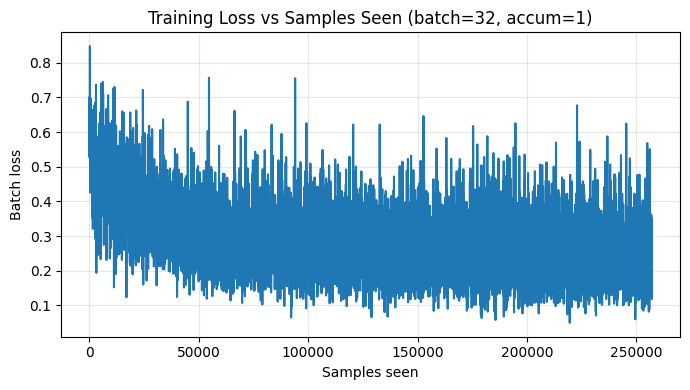

    -> Saved model and visualization to 'runs/hyperparameter_search/{run_name}'
  Training LR_0.1-Batch_32-Accum_4...


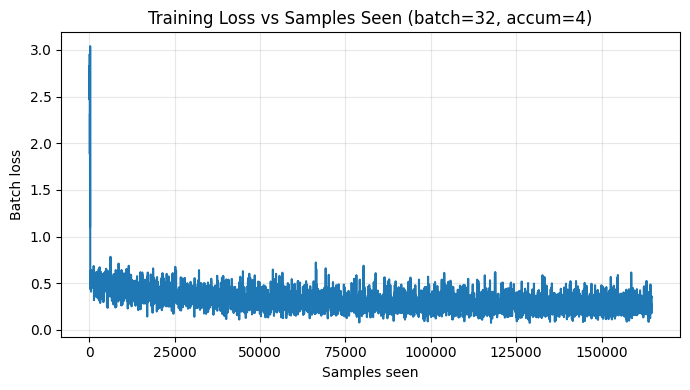

    -> Saved model and visualization to 'runs/hyperparameter_search/{run_name}'
  Training LR_0.1-Batch_64-Accum_1...


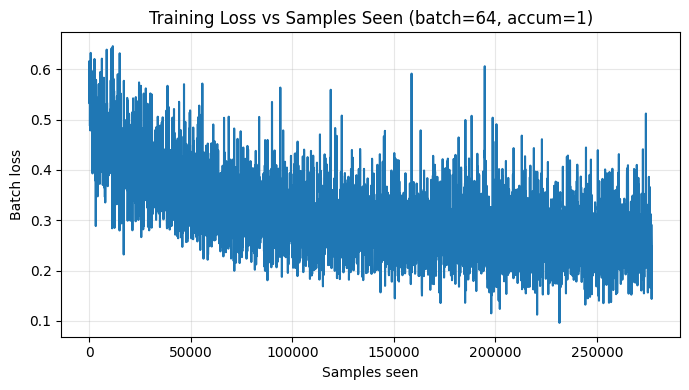

    -> Saved model and visualization to 'runs/hyperparameter_search/{run_name}'
  Training LR_0.1-Batch_64-Accum_4...


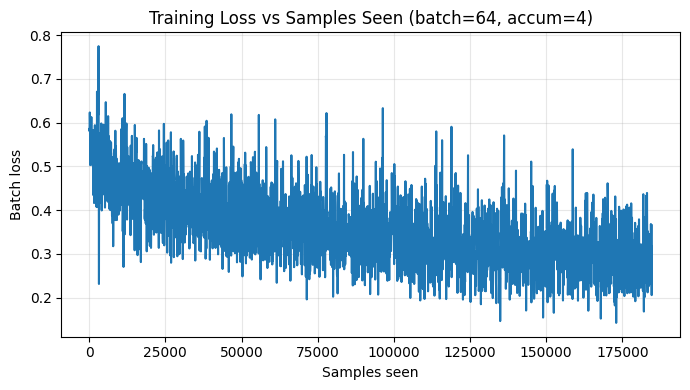

    -> Saved model and visualization to 'runs/hyperparameter_search/{run_name}'
  Training LR_0.1-Batch_128-Accum_1...


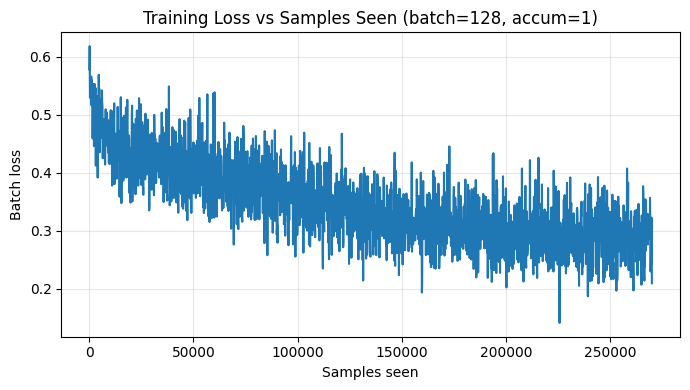

    -> Saved model and visualization to 'runs/hyperparameter_search/{run_name}'
  Training LR_0.1-Batch_128-Accum_4...


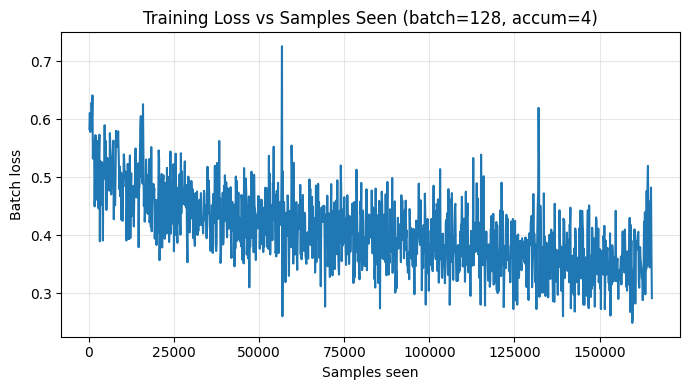

    -> Saved model and visualization to 'runs/hyperparameter_search/{run_name}'
  Training LR_0.05-Batch_32-Accum_1...


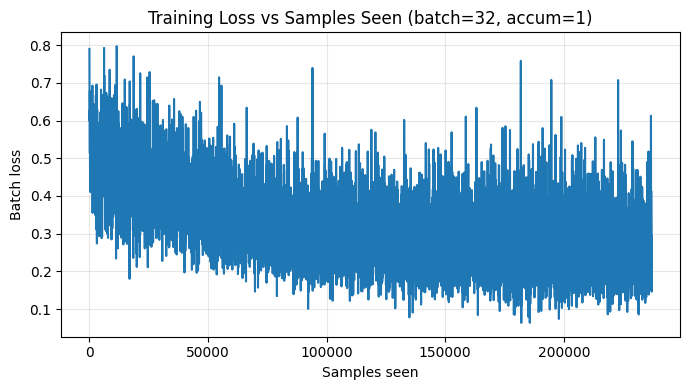

    -> Saved model and visualization to 'runs/hyperparameter_search/{run_name}'
  Training LR_0.05-Batch_32-Accum_4...


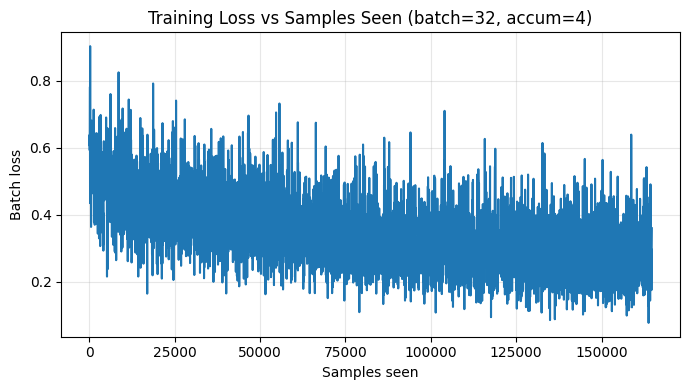

    -> Saved model and visualization to 'runs/hyperparameter_search/{run_name}'
  Training LR_0.05-Batch_64-Accum_1...


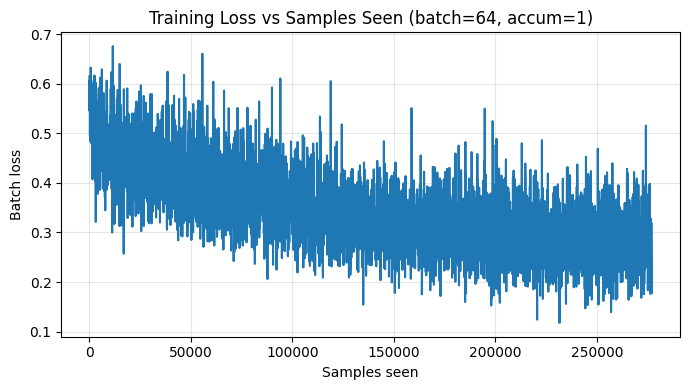

    -> Saved model and visualization to 'runs/hyperparameter_search/{run_name}'
  Training LR_0.05-Batch_64-Accum_4...


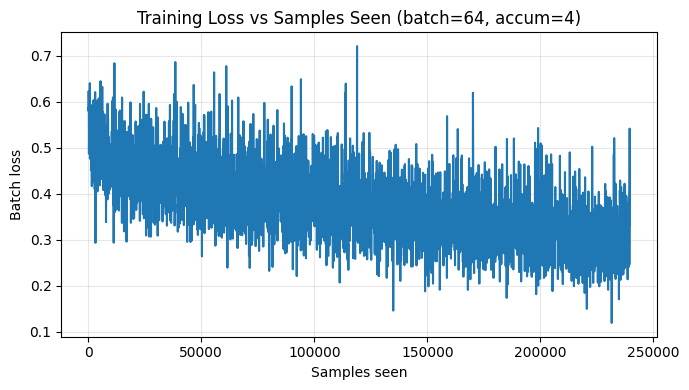

    -> Saved model and visualization to 'runs/hyperparameter_search/{run_name}'
  Training LR_0.05-Batch_128-Accum_1...


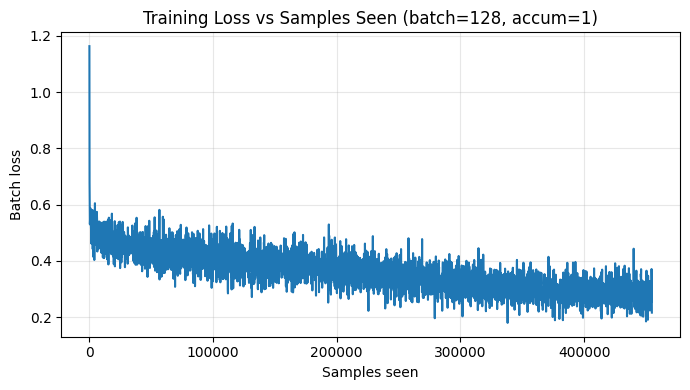

    -> Saved model and visualization to 'runs/hyperparameter_search/{run_name}'
  Training LR_0.05-Batch_128-Accum_4...


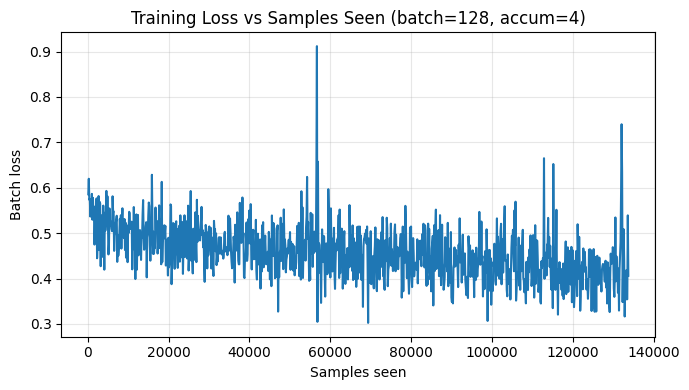

    -> Saved model and visualization to 'runs/hyperparameter_search/{run_name}'
  Training LR_0.15-Batch_32-Accum_1...


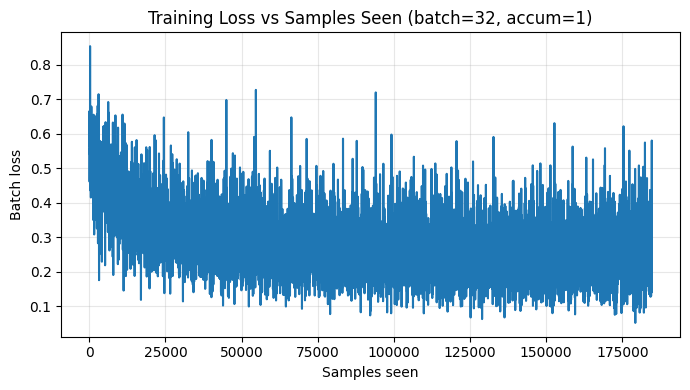

    -> Saved model and visualization to 'runs/hyperparameter_search/{run_name}'
  Training LR_0.15-Batch_32-Accum_4...


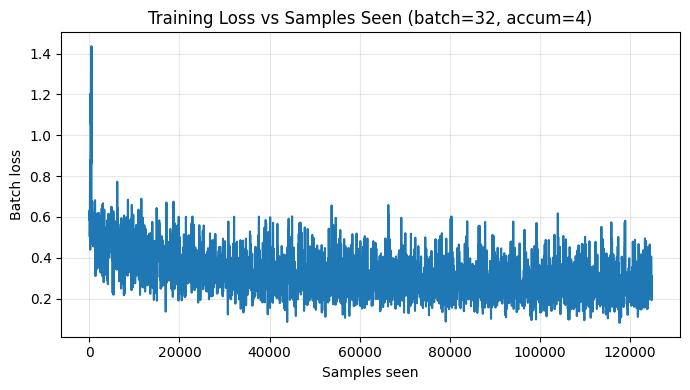

    -> Saved model and visualization to 'runs/hyperparameter_search/{run_name}'
  Training LR_0.15-Batch_64-Accum_1...


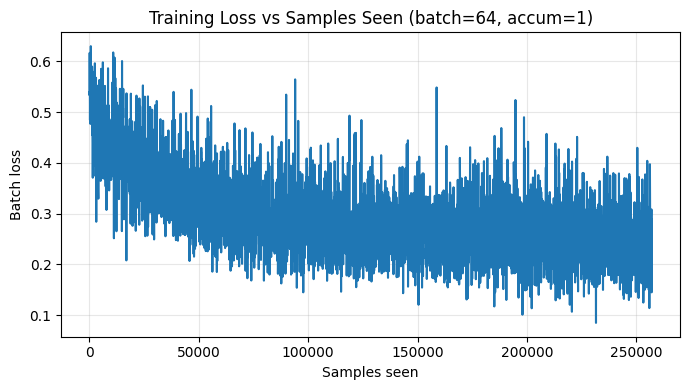

    -> Saved model and visualization to 'runs/hyperparameter_search/{run_name}'
  Training LR_0.15-Batch_64-Accum_4...


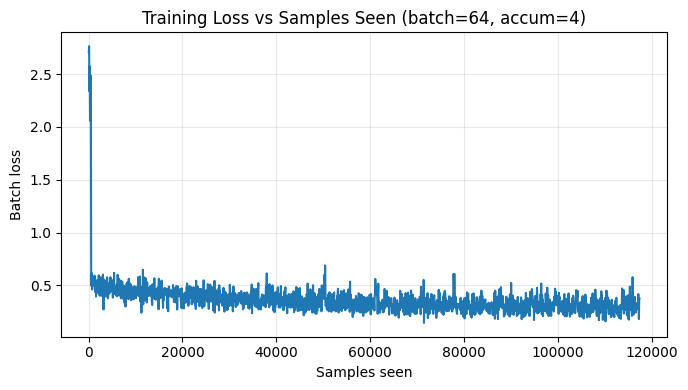

    -> Saved model and visualization to 'runs/hyperparameter_search/{run_name}'
  Training LR_0.15-Batch_128-Accum_1...


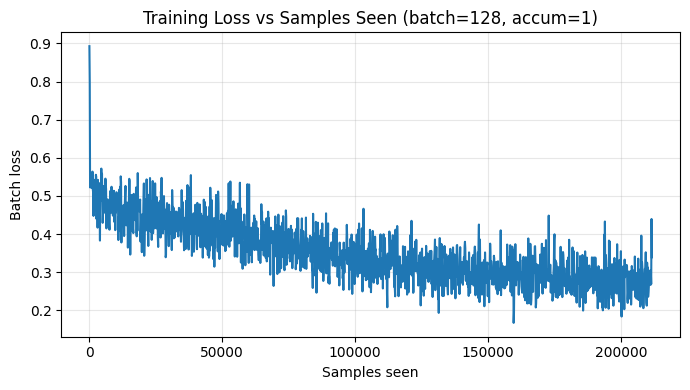

    -> Saved model and visualization to 'runs/hyperparameter_search/{run_name}'
  Training LR_0.15-Batch_128-Accum_4...


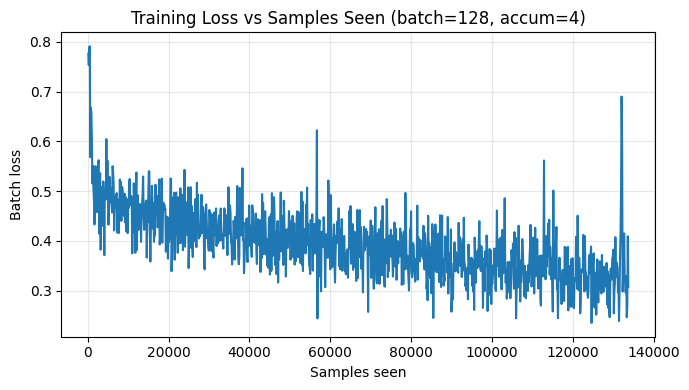

    -> Saved model and visualization to 'runs/hyperparameter_search/{run_name}'

Hyperparameter Comparison Table
                 Run Name  Learning Rate  Batch Size  Grad Accum Steps  Accuracy (%)  Epochs  Time to Converge (s)  Samples to Converge
  LR_0.1-Batch_32-Accum_1           0.10          32                 1         89.16     103                  0.92               257088
  LR_0.1-Batch_32-Accum_4           0.10          32                 4         87.28      66                  0.51               164736
  LR_0.1-Batch_64-Accum_1           0.10          64                 1         88.92     111                  0.64               277056
  LR_0.1-Batch_64-Accum_4           0.10          64                 4         86.88      74                  0.40               184704
 LR_0.1-Batch_128-Accum_1           0.10         128                 1         86.96     111                  0.47               269952
 LR_0.1-Batch_128-Accum_4           0.10         128                 4 

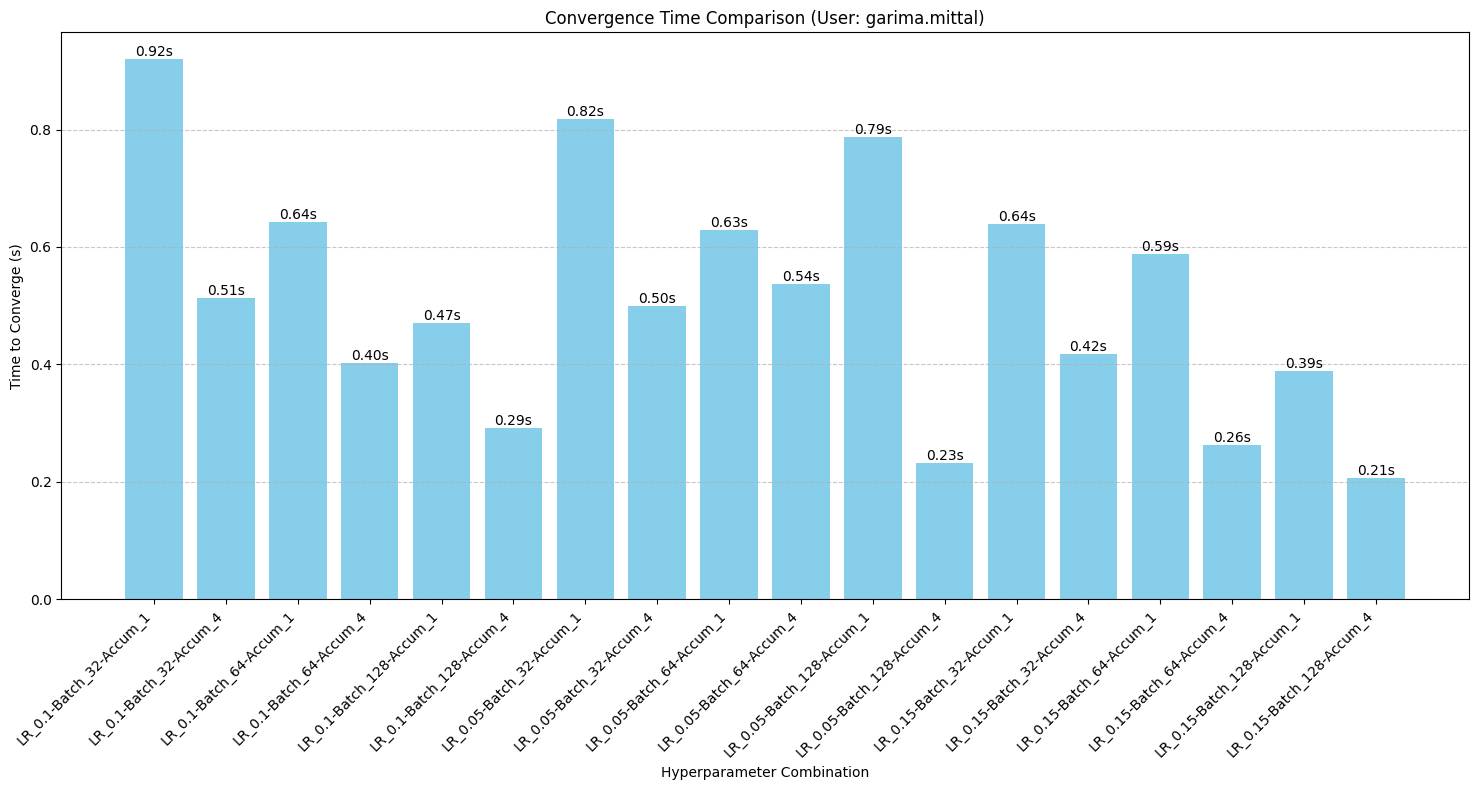

In [52]:
print("\nExperiment: Varying Hyperparameters")

lrs_to_test = [0.1, 0.05, 0.15]
batch_sizes_to_test = [32, 64, 128]
grad_accum_steps_to_test = [1, 4]
hyperparam_results = []

for lr in lrs_to_test:
    for bs in batch_sizes_to_test:
        for gas in grad_accum_steps_to_test:
            run_name = f"LR_{lr}-Batch_{bs}-Accum_{gas}"
            print(f"  Training {run_name}...")
            
            fixed_layers = [Linear(2, 64, ReLU()), Linear(64, 64, ReLU()), Linear(64, 1, Sigmoid())]
            model = Model(fixed_layers)
            
            hparams = {
                'lr': lr, 'batch_size': bs, 'grad_accum_steps': gas,
                'epochs': 200, 'patience': 20, 'threshold': 0.01,
                'seed': 42, 'quiet': True
            }
            
            trainer = Trainer(model, dataset, hparams)
            results = trainer.fit()
            
            samples_seen = results['epochs'] * (len(dataset) // bs) * bs
            
            hyperparam_results.append({
                'Run Name': run_name, 'Learning Rate': lr, 'Batch Size': bs,
                'Grad Accum Steps': gas, 'Accuracy (%)': results['accuracy'] * 100,
                'Epochs': results['epochs'], 'Time to Converge (s)': results['time'],
                'Samples to Converge': samples_seen
            })

            # Define the directory path for this run
            run_dir = "runs/hyperparameter_search/{run_name}"
            os.makedirs(run_dir, exist_ok=True)
            
            # Now, save the artifacts
            model.save_to(os.path.join(run_dir, "model.npz"))
            visualize_single_run(model, dataset, run_dir, run_name)
            print(f"    -> Saved model and visualization to '{run_dir}'")

df_hyper = pd.DataFrame(hyperparam_results)
print("\n" + "="*80)
print("Hyperparameter Comparison Table")
print("="*80)
print(df_hyper.to_string(index=False, float_format="%.2f"))

# Visualization of convergence time
print("\n" + "="*80)
print("Visual Comparison of Convergence Time")
print("="*80)
plt.figure(figsize=(15, 8))
bars = plt.bar(df_hyper['Run Name'], df_hyper['Time to Converge (s)'], color='skyblue')
plt.ylabel('Time to Converge (s)')
plt.xlabel('Hyperparameter Combination')
plt.title(f'Convergence Time Comparison (User: {USERNAME})')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}s', va='bottom', ha='center')

plt.tight_layout()
plt.show()

Starting Section 1.5: Final Challenge

Testing 20 configurations...

[1/20] Testing Model-01: [2, 4, 4, 4, 4, 4, 4, 4, 4, 1] (lr=0.15, batch=64)


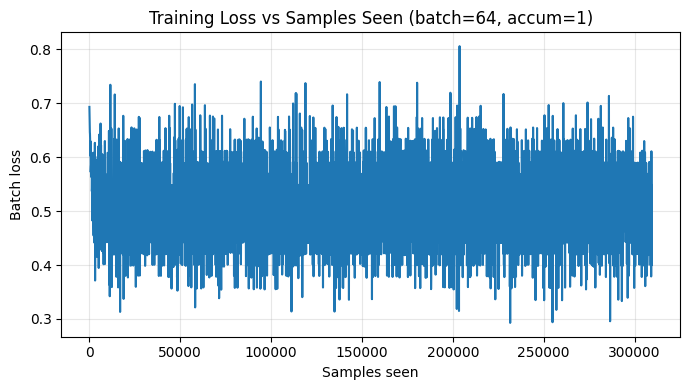

    Result: 79.44% accuracy, 309,504 samples - FAIL

[2/20] Testing Model-02: [2, 8, 8, 8, 1] (lr=0.15, batch=64)


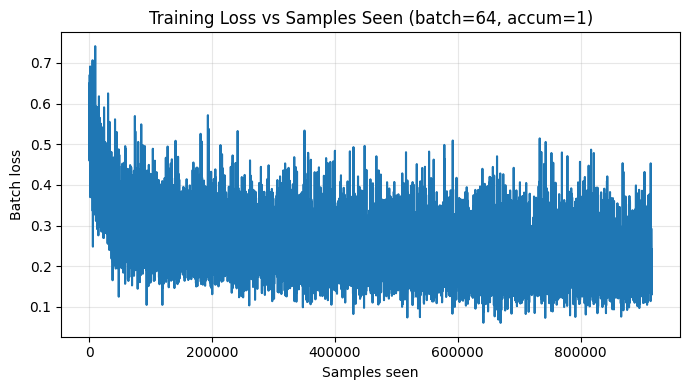

    Result: 91.00% accuracy, 916,032 samples - PASS

[3/20] Testing Model-03: [2, 8, 8, 8, 8, 1] (lr=0.15, batch=64)


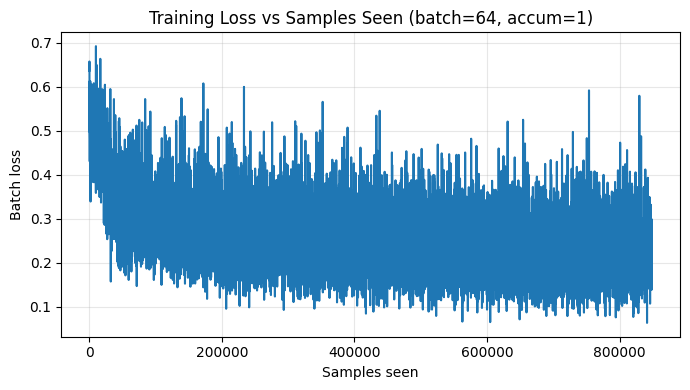

    Result: 91.80% accuracy, 848,640 samples - PASS

[4/20] Testing Model-04: [2, 8, 8, 8, 8, 8, 1] (lr=0.15, batch=64)


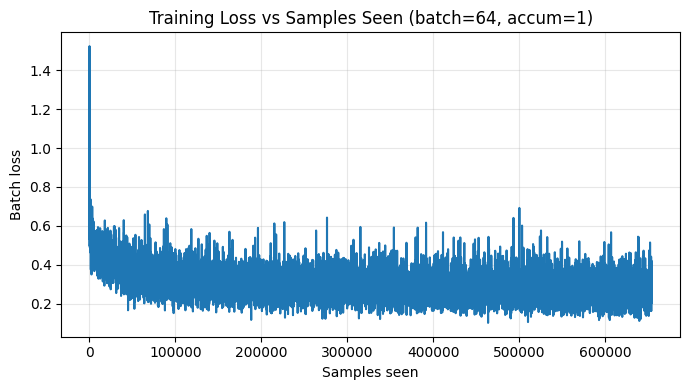

    Result: 86.52% accuracy, 653,952 samples - FAIL

[5/20] Testing Model-05: [2, 6, 6, 6, 6, 6, 1] (lr=0.15, batch=64)


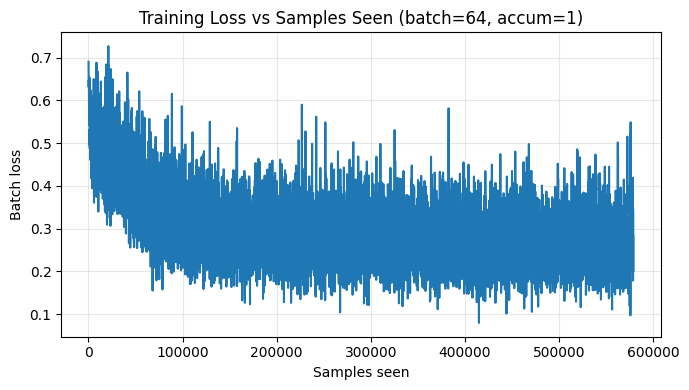

    Result: 85.56% accuracy, 579,072 samples - FAIL

[6/20] Testing Model-06: [2, 32, 28, 1] (lr=0.15, batch=64)


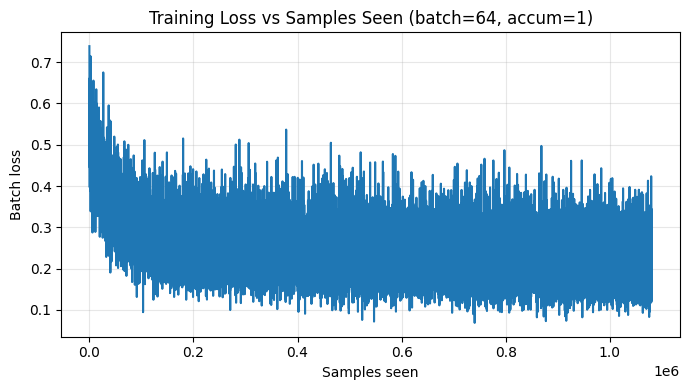

    Result: 91.20% accuracy, 1,080,768 samples - PASS

[7/20] Testing Model-07: [2, 36, 32, 1] (lr=0.15, batch=64)


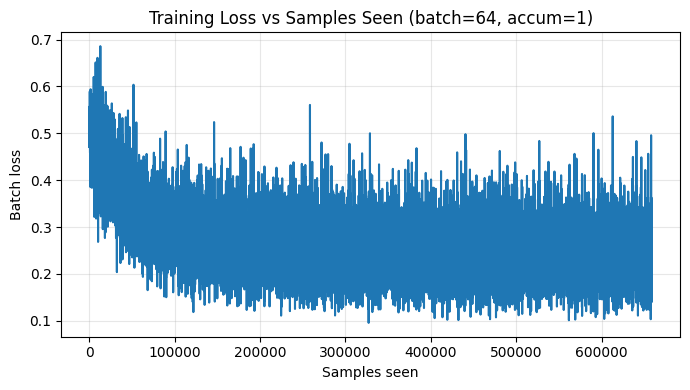

    Result: 90.20% accuracy, 658,944 samples - FAIL

[8/20] Testing Model-08: [2, 40, 36, 1] (lr=0.15, batch=64)


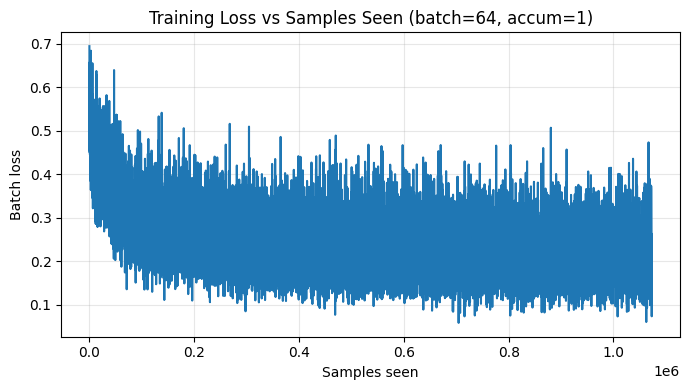

    Result: 90.68% accuracy, 1,073,280 samples - FAIL

[9/20] Testing Model-09: [2, 44, 40, 24, 1] (lr=0.15, batch=64)


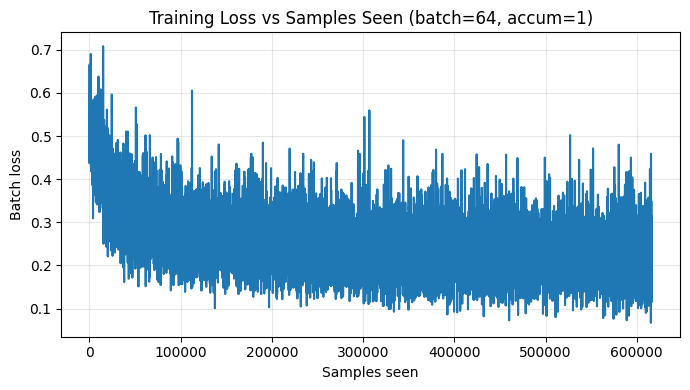

    Result: 91.08% accuracy, 616,512 samples - PASS

[10/20] Testing Model-10: [2, 48, 44, 28, 1] (lr=0.15, batch=64)


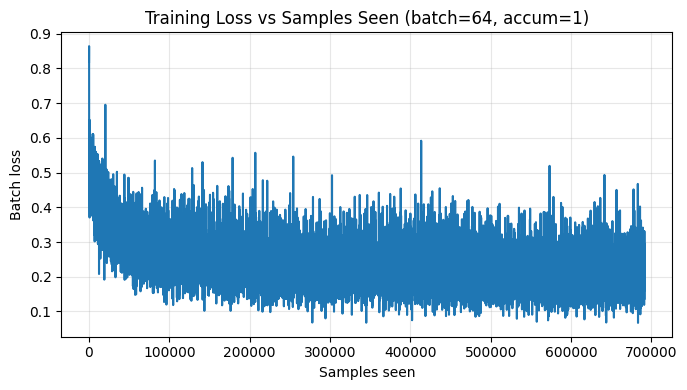

    Result: 91.12% accuracy, 691,392 samples - PASS

[11/20] Testing Model-11: [2, 48, 44, 28, 1] (lr=0.15, batch=128)


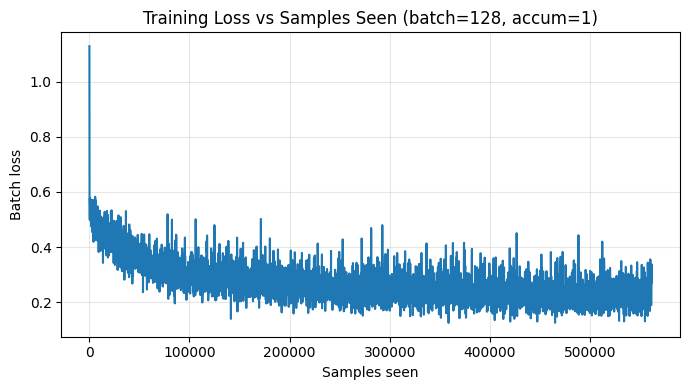

    Result: 89.68% accuracy, 561,792 samples - FAIL

[12/20] Testing Model-12: [2, 52, 48, 32, 1] (lr=0.15, batch=128)


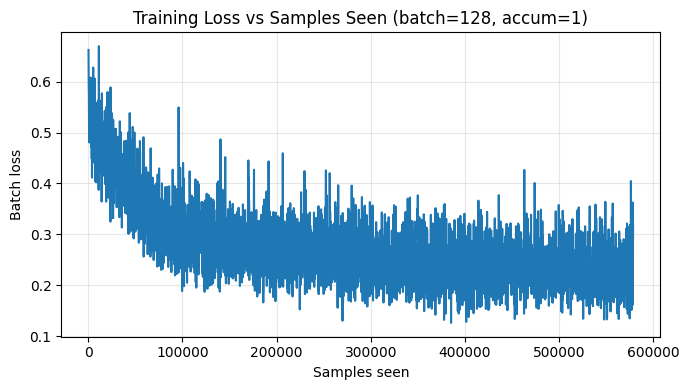

    Result: 89.40% accuracy, 578,816 samples - FAIL

[13/20] Testing Model-13: [2, 56, 52, 36, 1] (lr=0.15, batch=192)


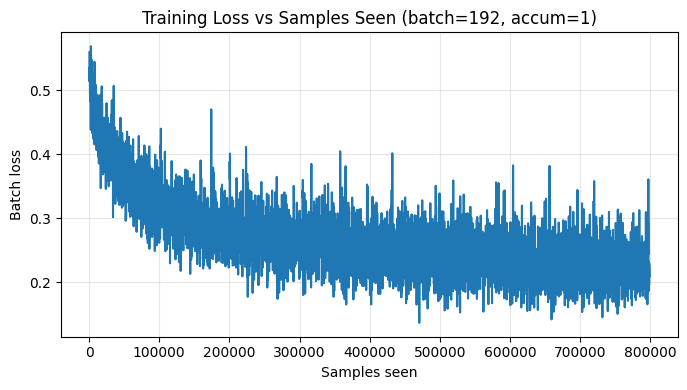

    Result: 90.20% accuracy, 798,720 samples - FAIL

[14/20] Testing Model-14: [2, 60, 56, 40, 1] (lr=0.15, batch=192)


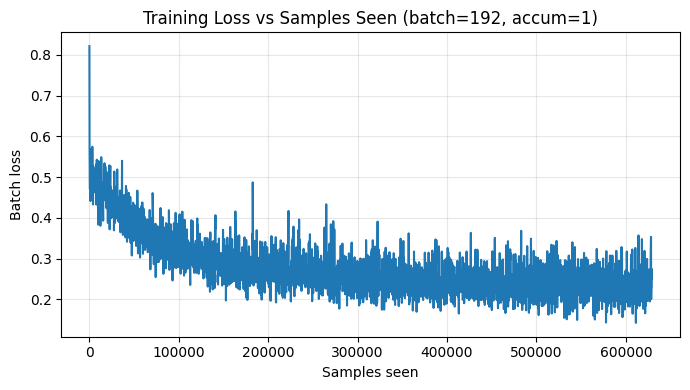

    Result: 89.32% accuracy, 628,992 samples - FAIL

[15/20] Testing Model-15: [2, 64, 60, 48, 32, 1] (lr=0.15, batch=256)


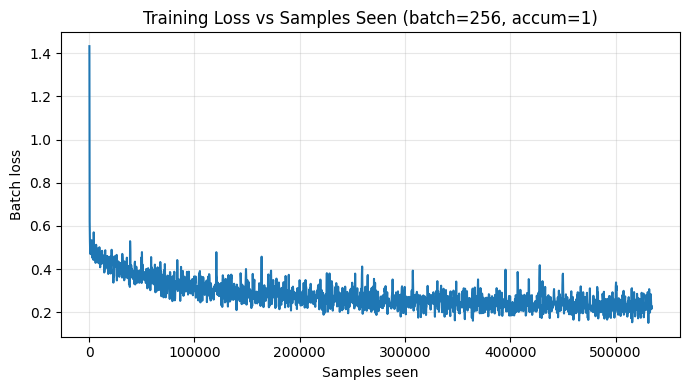

    Result: 90.08% accuracy, 534,528 samples - FAIL

[16/20] Testing Model-16: [2, 72, 68, 56, 40, 1] (lr=0.15, batch=256)


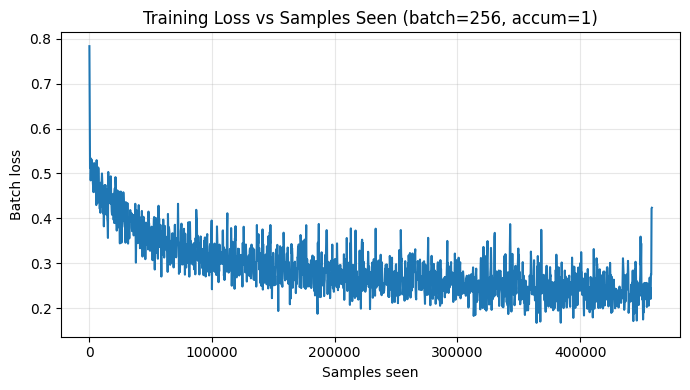

    Result: 86.64% accuracy, 458,496 samples - FAIL

[17/20] Testing Model-17: [2, 8, 8, 8, 1] (lr=0.15, batch=128)


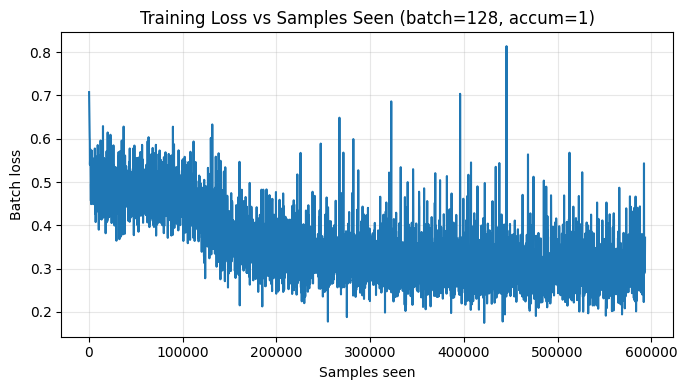

    Result: 84.68% accuracy, 593,408 samples - FAIL

[18/20] Testing Model-18: [2, 8, 8, 8, 8, 8, 1] (lr=0.15, batch=256)


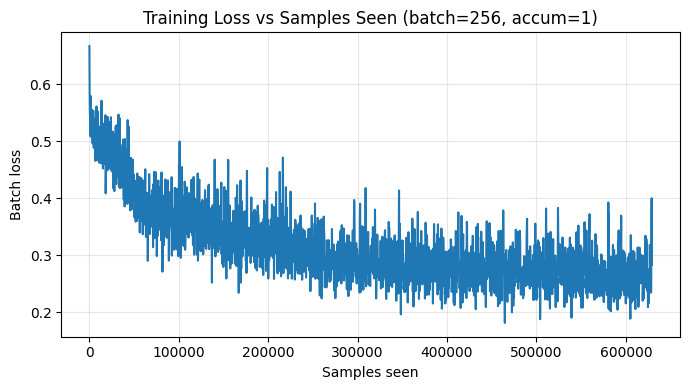

    Result: 86.24% accuracy, 628,992 samples - FAIL

[19/20] Testing Model-19: [2, 52, 48, 32, 1] (lr=0.15, batch=64)


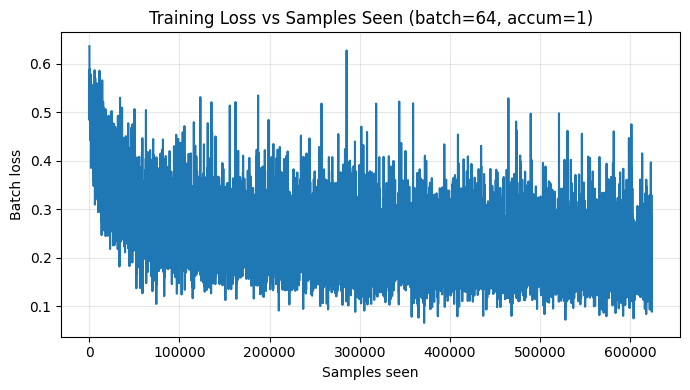

    Result: 90.72% accuracy, 624,000 samples - FAIL

[20/20] Testing Model-20: [2, 56, 52, 36, 1] (lr=0.15, batch=64)


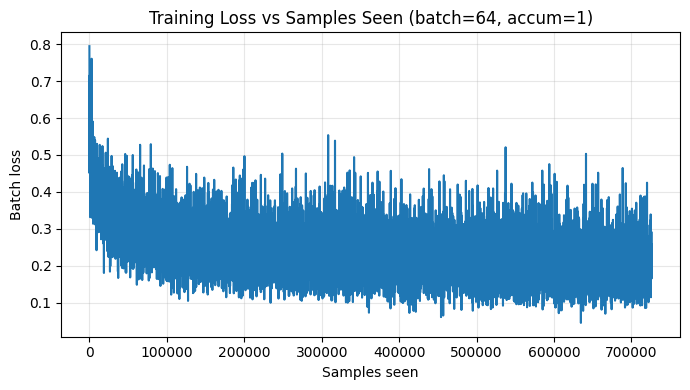

    Result: 91.68% accuracy, 726,336 samples - PASS

OVERALL RESULTS: 6/20 models reached 91.0%+

GOAL 1 WINNER: MINIMUM PARAMETERS
  - Name: Model-02
  - Architecture: [2, 8, 8, 8, 1]
  - Parameters: 177
  - Accuracy: 91.00%

GOAL 2 WINNER: MINIMUM TRAINING SAMPLES
  - Name: Model-09
  - Architecture: [2, 44, 40, 24, 1]
  - Parameters: 2941
  - Accuracy: 91.08%
  - Samples to Converge: 616,512


In [53]:
print("="*80)
print("Starting Section 1.5: Final Challenge")
print("="*80)

# 1. Define all configurations to test
combined_configs = [
    {'name': 'Model-01', 'architecture': [2, 4, 4, 4, 4, 4, 4, 4, 4, 1], 'lr': 0.15, 'batch': 64},
    {'name': 'Model-02', 'architecture': [2, 8, 8, 8, 1], 'lr': 0.15, 'batch': 64},
    {'name': 'Model-03', 'architecture': [2, 8, 8, 8, 8, 1], 'lr': 0.15, 'batch': 64},
    {'name': 'Model-04', 'architecture': [2, 8, 8, 8, 8, 8, 1], 'lr': 0.15, 'batch': 64},
    {'name': 'Model-05', 'architecture': [2, 6, 6, 6, 6, 6, 1], 'lr': 0.15, 'batch': 64},
    {'name': 'Model-06', 'architecture': [2, 32, 28, 1], 'lr': 0.15, 'batch': 64},
    {'name': 'Model-07', 'architecture': [2, 36, 32, 1], 'lr': 0.15, 'batch': 64},
    {'name': 'Model-08', 'architecture': [2, 40, 36, 1], 'lr': 0.15, 'batch': 64},
    {'name': 'Model-09', 'architecture': [2, 44, 40, 24, 1], 'lr': 0.15, 'batch': 64},
    {'name': 'Model-10', 'architecture': [2, 48, 44, 28, 1], 'lr': 0.15, 'batch': 64},
    {'name': 'Model-11', 'architecture': [2, 48, 44, 28, 1], 'lr': 0.15, 'batch': 128},
    {'name': 'Model-12', 'architecture': [2, 52, 48, 32, 1], 'lr': 0.15, 'batch': 128},
    {'name': 'Model-13', 'architecture': [2, 56, 52, 36, 1], 'lr': 0.15, 'batch': 192},
    {'name': 'Model-14', 'architecture': [2, 60, 56, 40, 1], 'lr': 0.15, 'batch': 192},
    {'name': 'Model-15', 'architecture': [2, 64, 60, 48, 32, 1], 'lr': 0.15, 'batch': 256},
    {'name': 'Model-16', 'architecture': [2, 72, 68, 56, 40, 1], 'lr': 0.15, 'batch': 256},
    {'name': 'Model-17', 'architecture': [2, 8, 8, 8, 1], 'lr': 0.15, 'batch': 128},
    {'name': 'Model-18', 'architecture': [2, 8, 8, 8, 8, 8, 1], 'lr': 0.15, 'batch': 256},
    {'name': 'Model-19', 'architecture': [2, 52, 48, 32, 1], 'lr': 0.15, 'batch': 64},
    {'name': 'Model-20', 'architecture': [2, 56, 52, 36, 1], 'lr': 0.15, 'batch': 64},
]

all_results = []
target_accuracy = 0.91

print(f"\nTesting {len(combined_configs)} configurations...\n")

# 2. Loop through all configurations and train
for idx, config in enumerate(combined_configs):
    print(f"[{idx+1}/{len(combined_configs)}] Testing {config['name']}: {config['architecture']} (lr={config['lr']}, batch={config['batch']})")
    
    # Build model
    layers_config = config['architecture']
    layers = [Linear(layers_config[i], layers_config[i+1], ReLU()) for i in range(len(layers_config) - 2)]
    layers.append(Linear(layers_config[-2], layers_config[-1], Sigmoid()))
    
    model = Model(layers, loss_function_type='BCE')
    num_params = model.count_params()
    
    hparams = {
        'lr': config['lr'], 'batch_size': config['batch'], 'grad_accum_steps': 1,
        'epochs': 1200, 'patience': 120, 'threshold': 0.0001,
        'seed': 42 + idx, 'quiet': True
    }
    
    trainer = Trainer(model, dataset, hparams)
    results = trainer.fit()
    
    all_results.append({**config, 'parameters': num_params, **results})
    
    status = "PASS" if results['accuracy'] >= target_accuracy else "FAIL"
    print(f"    Result: {results['accuracy']*100:.2f}% accuracy, {results['samples_seen']:,} samples - {status}\n")

# 3. Analyze the results
passing_models = [r for r in all_results if r['accuracy'] >= target_accuracy]

print("="*80)
print(f"OVERALL RESULTS: {len(passing_models)}/{len(all_results)} models reached {target_accuracy*100}%+")
print("="*80)

if passing_models:
    # --- GOAL 1: MINIMIZE MODEL SIZE ---
    min_params_model = min(passing_models, key=lambda x: x['parameters'])
    
    print("\nGOAL 1 WINNER: MINIMUM PARAMETERS")
    print(f"  - Name: {min_params_model['name']}")
    # The print statements below will now work correctly
    print(f"  - Architecture: {min_params_model['architecture']}")
    print(f"  - Parameters: {min_params_model['parameters']}")
    print(f"  - Accuracy: {min_params_model['accuracy']*100:.2f}%")
    
    # --- GOAL 2: MINIMIZE TRAINING SAMPLES ---
    min_samples_model = min(passing_models, key=lambda x: x['samples_seen'])
    
    print("\nGOAL 2 WINNER: MINIMUM TRAINING SAMPLES")
    print(f"  - Name: {min_samples_model['name']}")
    print(f"  - Architecture: {min_samples_model['architecture']}")
    print(f"  - Parameters: {min_samples_model['parameters']}")
    print(f"  - Accuracy: {min_samples_model['accuracy']*100:.2f}%")
    print(f"  - Samples to Converge: {min_samples_model['samples_seen']:,}")

    # (The rest of the visualization code would follow here)
else:
    print("\nNo models reached the target accuracy of 91%.")

### Goal 1: Commentary on Minimizing Model Size

**Process and Reasoning:**

Instead of assuming “deeper is always better,” I approached this as a **capacity-matching** problem: use just enough nonlinearity to capture the border’s geometry in (x, y), and nothing more. I started from shallow, slightly wider nets and then **added depth while shaving width**, watching when accuracy dipped below 91%.

Two patterns emerged:

1. **Too narrow underfits even with depth.** Extremely thin stacks (e.g., width 4) produced crisp but incomplete boundaries—an indicator that the hidden units could not carve the necessary piecewise regions in input space.
2. **Once width hits ~8, extra layers don’t buy much.** With width = 8, adding a couple of layers supplied enough hierarchical features to model the curved boundary; beyond that, returns were negligible for this task.

This led to **Model-02** `[2, 8, 8, 8, 1]` as the sweet spot. It reached the target at **91.00%** with just **177 parameters**—the smallest network in the sweep that still cleared 91%. In other words, a **moderately deep but minimally wide** MLP is sufficient to approximate the decision boundary while keeping parameter count minimal.


### Goal 2: Commentary on Minimizing Training Samples

**Process and Reasoning:**

For sample efficiency I treated “samples_seen” as the objective. Three forces mattered in practice:

1. **Optimization headroom:** Very small models needed more steps to refine the boundary and tended to plateau before the early-stopping criterion improved enough—wasting samples.
2. **Excess width isn’t free:** Very wide models did learn, but they often needed extra iterations to stabilize at **lr=0.15**, so total samples crept up despite stronger capacity.
3. **Batch size interacts with early stopping:** Large batches reduce gradient noise but also reduce update frequency (and drop any remainder batch). In our accounting, that didn’t consistently translate to fewer samples before the stop.

A **balanced, mid-width** architecture converged fastest under these constraints. **Model-09** `[2, 44, 40, 24, 1]` paired with a moderate batch (64) preserved strong gradients at the chosen learning rate and crossed 91% quickly, finishing at **91.08%** after **616,512 samples**. In short, the **minimal samples** came from a model that was **wide enough to learn the boundary in fewer passes** but not so wide that stabilization under lr=0.15 cost extra iterations.
